In [34]:
import os.path as op
import numpy as np
from scipy import stats as stats
from scipy.stats import pearsonr
from functools import partial
import pandas as pd
import mne
import matplotlib.pyplot as plt
from mne.minimum_norm import make_inverse_operator, apply_inverse, source_band_induced_power, apply_inverse_epochs,compute_source_psd, compute_source_psd_epochs
from mne.datasets import fetch_fsaverage
import pickle
from scipy.stats import sem
from mne import spatial_src_adjacency
from mne.stats import spatio_temporal_cluster_test, summarize_clusters_stc
import xarray as xr

subjects_dir = '/home/gopalar/mne_data/'
subject = "fsaverage"
trans = "fsaverage"  # MNE has a built-in fsaverage transformation
src_fname = subjects_dir+'/'+subject+"/bem"+"/fsaverage-ico-4-src.fif"
bem = subjects_dir+'/'+subject+"/bem"+"/fsaverage-5120-5120-5120-bem-sol.fif"
src = mne.read_source_spaces(src_fname)


import statsmodels.api as sm
import statsmodels.formula.api as smf
from mpl_toolkits.axes_grid1 import ImageGrid, inset_locator, make_axes_locatable
labels = mne.read_labels_from_annot(
        "fsaverage", "aparc", "both", subjects_dir=subjects_dir
    )
labels = [label for label in labels if 'unknown' not in label.name]


# Get valid vertices for both hemispheres
valid_verts = [[], []]
for label in labels:
    hemi_idx = 0 if label.hemi == 'lh' else 1
    valid_verts[hemi_idx].extend(label.vertices)

# Remove duplicates and sort
valid_verts = [np.array(sorted(set(valid_verts[0]))), np.array(sorted(set(valid_verts[1])))]


def mask_stc_vertices(stc, valid_verts): # full fsaverage
    """Set data to zero for vertices not in the atlas."""
    masked_data = stc.data.copy()
    offset = 0  # to track row indices in stc.data

    for hemi_idx, hemi_verts in enumerate(stc.vertices):
        invalid_mask = ~np.isin(hemi_verts, valid_verts[hemi_idx])
        for idx, invalid in enumerate(invalid_mask):
            masked_data[offset:offset+len(hemi_verts)][invalid_mask] = 0
        offset += len(hemi_verts)

    stc._data = masked_data
    return stc




    Reading a source space...
    [done]
    Reading a source space...
    [done]
    2 source spaces read
Reading labels from parcellation...
   read 35 labels from /home/gopalar/mne_data/fsaverage/label/lh.aparc.annot
   read 34 labels from /home/gopalar/mne_data/fsaverage/label/rh.aparc.annot


In [43]:
#COG method single subject, compute paf, paf_power for each vertex first then average

control_stcs, control_PAF, control_PAF_power, control_stc_all, control_stcs_raw = {}, {}, {}, [], {}
avg_stc_control, avg_stc_control1 = 0, 0

# Parameters
sub = 'PAM_NR001_cm_RH'
norm=True
nfl, nfh = 1, 40 # normalization band for PAF power calculation
#nfl, nfh = 6.8, 13.5  # normalization band for PAF power calculation

fl, fh = 8, 12  # Alpha band
bw = 0.5

subjects_dir = '/home/gopalar/mne_data/'
psd_dir = f'/mnt/isilon/w_neuro/gopalarlab/Migraine_project/Data_Analysis/{sub}'
fname_stc = psd_dir + '/' + "SPONT_2_psd_dSPM"

subject = "fsaverage"
stc = mne.read_source_estimate(fname_stc, subject=subject) # (n_vertices, n_freqs)

if norm:
    stc1 = stc.copy().crop(nfl, nfh)
    stc_norm = stc1.copy().sum()
    stc = 100 * stc / stc_norm.data
else:
    stc_band = stc.copy().crop(nfl, nfh)
    stc_norm = stc_band.copy().sum()


stc = mask_stc_vertices(stc, valid_verts)
stc_alpha = stc.copy().crop(fl, fh)


# PAF
"""
valid_mask = stc_alpha.data.sum(axis=1) != 0  # rows with actual signal
source_time_max1 = np.full(stc_alpha.data.shape[0], np.nan)
source_time_max1[valid_mask] = (
    np.multiply(stc_alpha.data[valid_mask], stc_alpha.times).sum(axis=1)
    / stc_alpha.data[valid_mask].sum(axis=1)
)
#source_time_max1 = np.multiply(stc_alpha.data, stc_alpha.times).sum(axis=1) / stc_alpha.data.sum(axis=1)
source_vert_max1 = []
for i in range(stc_alpha.data.shape[0]):
    if stc_alpha.data[i, :].sum() == 0:
        source_vert_max1.append(np.nan)
        continue
    idx_max = np.argmax(stc_alpha.data[i, :])
    paf_freq = stc_alpha.times[idx_max]
    freqs = stc_alpha.times
    in_bw = np.where((freqs >= paf_freq - bw) & (freqs <= paf_freq + bw))[0]
    paf_power_val = np.mean(stc_alpha.data[i, in_bw])
    if not norm:
        paf_power_val = 100 * paf_power_val / stc_norm.data[i]
    source_vert_max1.append(paf_power_val)
"""

source_time_max1 = np.full(stc_alpha.data.shape[0], np.nan)
source_vert_max1 = np.full(stc_alpha.data.shape[0], np.nan)
freqs = stc_alpha.times

for i in range(stc_alpha.data.shape[0]):
    if stc_alpha.data[i, :].sum() == 0:
        continue
    paf_freq = np.multiply(stc_alpha.data[i, :], freqs).sum() / stc_alpha.data[i, :].sum()
    source_time_max1[i] = paf_freq

    in_bw = np.where((freqs >= paf_freq - bw) & (freqs <= paf_freq + bw))[0]
    paf_power_val = np.mean(stc_alpha.data[i, in_bw])
    if not norm:
        paf_power_val = 100 * paf_power_val / stc_norm.data[i]
    source_vert_max1[i] = paf_power_val


control_PAF = np.nanmean(source_time_max1)
control_PAF_power = np.nanmean(source_vert_max1)

control_PAF_indcog=control_PAF
control_PAF_power_indcog=control_PAF_power

if not np.isnan(control_PAF):
    print(f"ind COG PAF: {control_PAF:.2f} Hz")
    print(f"ind COG PAF power: {control_PAF_power:.3g}")
else:
    print("No alpha peak detected in averaged whole-cortex PSD.")

ind COG PAF: 9.61 Hz
ind COG PAF power: 0.983


In [39]:
#COG method single subject (whole cortex, average PSD from all vertices first, then compute paf, pafpower)

control_stcs, control_PAF, control_PAF_power, control_stc_all, control_stcs_raw = {}, {}, {}, [], {}
avg_stc_control, avg_stc_control1 = 0, 0

# Parameters
sub = 'PAM_NR001_cm_RH'
norm = True
nfl, nfh = 1, 40  # normalization band for PAF power calculation
#nfl, nfh = 6.8, 13.5  # normalization band for PAF power calculation

fl, fh = 8, 12  # Alpha band
bw = 0.5

subjects_dir = '/home/gopalar/mne_data/'
psd_dir = f'/mnt/isilon/w_neuro/gopalarlab/Migraine_project/Data_Analysis/{sub}'
fname_stc = psd_dir + '/' + "SPONT_2_psd_dSPM"

subject = "fsaverage"
stc = mne.read_source_estimate(fname_stc, subject=subject)  # (n_vertices, n_freqs)

if norm:
    stc1 = stc.copy().crop(nfl, nfh)
    stc_norm = stc1.copy().sum()
    stc = 100 * stc / stc_norm.data
else:
    stc_band = stc.copy().crop(nfl, nfh)
    stc_norm = stc_band.copy().sum()

stc = mask_stc_vertices(stc, valid_verts)
stc_alpha = stc.copy().crop(fl, fh)

# PAF via CoG, on the vertex-AVERAGED PSD
freqs = stc_alpha.times

# Average across vertices first -- exclude masked (all-zero) vertices from the average
valid_rows = stc_alpha.data.sum(axis=1) != 0
mean_psd_alpha = np.nanmean(stc_alpha.data[valid_rows, :], axis=0)

if mean_psd_alpha.sum() == 0:
    control_PAF, control_PAF_power = np.nan, np.nan
    print("Averaged alpha-band PSD is all zero -- cannot compute PAF.")
else:
    control_PAF = np.multiply(mean_psd_alpha, freqs).sum() / mean_psd_alpha.sum()

    in_bw = np.where((freqs >= control_PAF - bw) & (freqs <= control_PAF + bw))[0]
    control_PAF_power = np.mean(mean_psd_alpha[in_bw])

    if not norm:
        # NOTE: stc_norm here is the FULL-cortex normalization sum -- averaging
        # it the same way as the PSD keeps units consistent with mean_psd_alpha
        mean_norm = np.nanmean(stc_norm.data[valid_rows])
        control_PAF_power = 100 * control_PAF_power / mean_norm

control_PAF_cog=control_PAF
control_PAF_power_cog=control_PAF_power

if not np.isnan(control_PAF):
    print(f"COG PAF: {control_PAF:.2f} Hz")
    print(f"COG PAF power: {control_PAF_power:.3g}")
else:
    print("No alpha peak detected in averaged whole-cortex PSD.")

COG PAF: 9.56 Hz
COG PAF power: 0.877


In [40]:
# FOOOF method single subject

control_stcs, control_PAF, control_PAF_power, control_stc_all, control_stcs_raw = {}, {}, {}, [], {}
avg_stc_control, avg_stc_control1 = 0, 0

# Parameters
sub = 'PAM_NR001_cm_RH'
norm = True
nfl, nfh = 1, 40  # normalization band for PAF power calculation
#nfl, nfh = 6.8, 13.5  # normalization band for PAF power calculation

fl, fh = 8, 12  # Alpha band
bw = 0.5

subjects_dir = '/home/gopalar/mne_data/'
psd_dir = f'/mnt/isilon/w_neuro/gopalarlab/Migraine_project/Data_Analysis/{sub}'
fname_stc = psd_dir + '/' + "SPONT_2_psd_dSPM"

subject = "fsaverage"
stc = mne.read_source_estimate(fname_stc, subject=subject)  # (n_vertices, n_freqs)

if norm:
    stc1 = stc.copy().crop(nfl, nfh)
    stc_norm = stc1.copy().sum()
    stc = 100 * stc / stc_norm.data
else:
    stc_band = stc.copy().crop(nfl, nfh)
    stc_norm = stc_band.copy().sum()

stc = mask_stc_vertices(stc, valid_verts)

# PAF via FOOOF, on the vertex-AVERAGED PSD
from fooof import FOOOF
import numpy as np

def get_paf_fooof(psd, freqs, freq_range=(1, 40), peak_range=(6, 13)):
    """
    Fit FOOOF model to one PSD curve, extract alpha peak frequency and power.
    psd: 1D array of power values (must be > 0, linear scale)
    freqs: 1D array of corresponding frequencies
    """
    fm = FOOOF(peak_width_limits=(1, 8), max_n_peaks=6, min_peak_height=0.05,
               aperiodic_mode='fixed', verbose=False)

    fm.fit(freqs, psd, freq_range)
    peaks = fm.peak_params_  # [center_freq, power, bandwidth] per row

    if len(peaks) == 0:
        return np.nan, np.nan, np.nan

    in_alpha = peaks[(peaks[:, 0] >= peak_range[0]) & (peaks[:, 0] <= peak_range[1])]
    if len(in_alpha) == 0:
        return np.nan, np.nan, np.nan

    best_peak = in_alpha[np.argmax(in_alpha[:, 1])]
    paf_freq = best_peak[0]
    paf_power = best_peak[1]  # power ABOVE the aperiodic fit, not raw PSD power

    return paf_freq, paf_power, fm.r_squared_


freqs = stc.times      # full frequency range, NOT cropped to alpha -- FOOOF needs the wide range
psd_data = stc.data    # (n_vertices, n_freqs)

# Average across ALL vertices first (masked/zero vertices contribute 0 are excluded)
valid_rows = psd_data.sum(axis=1) != 0
mean_psd = np.nanmean(psd_data[valid_rows, :], axis=0)
print(f"Averaging over {valid_rows.sum()} / {psd_data.shape[0]} valid vertices")

if mean_psd.sum() == 0 or np.any(mean_psd <= 0):
    control_PAF, control_PAF_power, r2 = np.nan, np.nan, np.nan
    print("Averaged PSD has zero/non-positive values -- cannot fit FOOOF.")
else:
    control_PAF, control_PAF_power, r2 = get_paf_fooof(
        mean_psd, freqs, freq_range=(1, 40), peak_range=(6, 13))

if not np.isnan(control_PAF):
    print(f"FOOOF PAF: {control_PAF:.2f} Hz")
    print(f"FOOOF PAF power (above aperiodic): {control_PAF_power:.3g}")
    print(f"Fit R²: {r2:.3f}")
else:
    print("No alpha peak detected in averaged whole-cortex PSD.")

control_PAF_fooof=control_PAF
control_PAF_power_fooof=control_PAF_power

Averaging over 4687 / 5124 valid vertices
FOOOF PAF: 9.10 Hz
FOOOF PAF power (above aperiodic): 0.629
Fit R²: 0.978


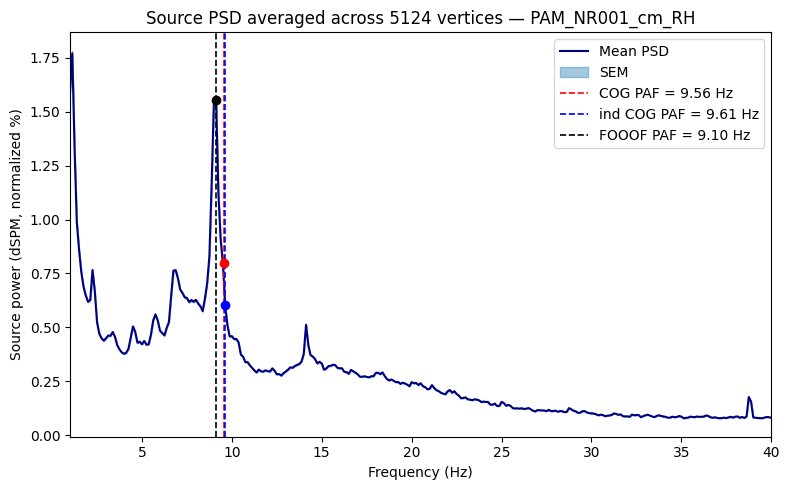

In [46]:
#plot global psd and show paf/paf power for single subject chosen above

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import sem

# stc.data shape: (n_vertices, n_freqs) -- using the masked/normalized stc from your PAF script
psd_data = stc.data
freqs = stc.times

mean_psd = np.mean(psd_data, axis=0)
sem_psd = sem(psd_data, axis=0)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(freqs, mean_psd, color='navy', linewidth=1.5, zorder=2, label='Mean PSD')
ax.fill_between(freqs, mean_psd - sem_psd, mean_psd + sem_psd,
                 color='C0', alpha=0.4, zorder=1, label='SEM')

# --- Mark PAF (peak alpha frequency) ---
ax.axvline(control_PAF_cog, color='red', linestyle='--', linewidth=1.2,
           label=f'COG PAF = {control_PAF_cog:.2f} Hz')
ax.axvline(control_PAF_indcog, color='blue', linestyle='--', linewidth=1.2,
           label=f'ind COG PAF = {control_PAF_indcog:.2f} Hz')
ax.axvline(control_PAF_fooof, color='black', linestyle='--', linewidth=1.2,
           label=f'FOOOF PAF = {control_PAF_fooof:.2f} Hz')

# --- Annotate PAF power at that frequency ---
# Find the y-value on the mean curve closest to control_PAF for placing the marker
paf_idx = np.argmin(np.abs(freqs - control_PAF_cog))
ax.plot(control_PAF_cog, mean_psd[paf_idx], 'ro', zorder=3)

paf_idx = np.argmin(np.abs(freqs - control_PAF_indcog))
ax.plot(control_PAF_indcog, mean_psd[paf_idx], 'bo', zorder=3)

paf_idx = np.argmin(np.abs(freqs - control_PAF_fooof))
ax.plot(control_PAF_fooof, mean_psd[paf_idx], 'ko', zorder=3)

"""
# Text box with both values
textstr = f'PAF: {control_PAF:.2f} Hz\nPAF power: {control_PAF_power:.3g}'
ax.text(0.98, 0.95, textstr, transform=ax.transAxes,
        fontsize=10, verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray'))
"""
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Source power (dSPM, normalized %)' if norm else 'Source power (dSPM)')
ax.set_title(f'Source PSD averaged across {psd_data.shape[0]} vertices — {sub}')
ax.legend(loc='upper right')
ax.set_xlim(freqs[0], freqs[-1])

plt.tight_layout()
#plt.savefig(f'{psd_dir}/SPONT_2_psd_dSPM_avg_PAF.png', dpi=300)
plt.show()